In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import storage
import io

In [2]:
import google.auth
from google.auth import impersonated_credentials

credentials, project = google.auth.default()
print(credentials, project)

service_account = "le-wagon-bootcamp@le-wagon-2303.iam.gserviceaccount.com"
signing_credentials = impersonated_credentials.Credentials(
    source_credentials=credentials,
    target_principal=service_account,
    target_scopes=["https://www.googleapis.com/auth/cloud-platform"],
    lifetime=3600,
)

bucket_client = storage.Client(project='le-wagon-2303',  credentials=signing_credentials)
bucket = bucket_client.bucket('sm-optimizer-processed')

clean_blob = bucket.blob("posts_clean.csv")
df = pd.read_csv(clean_blob.open('rb'))
df.head()


<google.oauth2.service_account.Credentials object at 0xffff88120080> wagon-ds-2026


,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,cost_nzd,views,hours,engagement
0,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/729678446160620/,@jacobkneepkens crosses the chalk 🤙,NaN,38409.0,64.3328,682.0
1,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/850774540642042/,@nanaiseturo 💨,NaN,235384.0,544.8062,3800.0
2,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1120082556960744/,a classic rugby training drill 🏉,NaN,274028.0,712.1043,3261.0
3,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1191989952906685/,"a great kick, a great backdrop 🎨",NaN,281319.0,623.9321,4929.0
4,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1728500341153571/,a skill and a half 🚀,NaN,438181.0,894.3045,9850.0


In [3]:
### existing descriptions JSONs
yt_description_blobs = bucket_client.list_blobs('sm-optimizer-processed', prefix="gemini-descriptions/youtube")
yt_description_keys = [f"{blob.name.split('/')[-1].removesuffix('.json')}" for blob in yt_description_blobs]

tt_description_blobs = bucket_client.list_blobs('sm-optimizer-processed', prefix="gemini-descriptions/tiktok")
tt_description_keys = [f"{blob.name.split('/')[-1].removesuffix('.json')}" for blob in tt_description_blobs]

fb_description_blobs = bucket_client.list_blobs('sm-optimizer-processed', prefix="gemini-descriptions/facebook")
fb_description_keys = [f"{blob.name.split('/')[-1].removesuffix('.json')}" for blob in fb_description_blobs]

ig_description_blobs = bucket_client.list_blobs('sm-optimizer-processed', prefix="gemini-descriptions/instagram")
ig_description_keys = [f"{blob.name.split('/')[-1].removesuffix('.json')}" for blob in ig_description_blobs]

all_description_keys = yt_description_keys + tt_description_keys + fb_description_keys + ig_description_keys
print(all_description_keys[12], all_description_keys[-40])
print('descriptions in bucket:', len([k for k in all_description_keys if k]))

-D1tJ_VPX9A 4AeO0Z_R7wA
descriptions in bucket: 160


In [4]:
print(df.columns)

Index(['campaign', 'year', 'page', 'platform', 'media_type', 'category_l0',
       'category_l1', 'category_l2', 'url', 'content', 'cost_nzd', 'views',
       'hours', 'engagement'],
      dtype='object')


In [5]:
# {
#   "play_by_play": "",
#   "content_theme": [],
#   "format_access": [],
#   "people": [],
#   "brands": [],
#   "event": [],
#   "tone": [],
#   "context": [],
#   "overall_team": [],
#   "audio_format": [],
# }

import json
import re

PLATFORM_TO_PREFIX = {"YT": "yt", "TT": "tt", "FB": "fb", "IG": "ig"}
PLATFORM_TO_FOLDER = {"YT": "youtube", "TT": "tiktok", "FB": "facebook", "IG": "instagram"}
JSON_LIST_FIELDS = [
    "content_theme", "format_access", "people", "brands",
    "event", "tone", "context", "overall_team", "audio_format",
]
URL_ID_PATTERNS = {
    "FB": r"/(?:reel|video|videos|posts|share|v)/([\w-]+)",
    "YT": r"(?:v=|youtu\.be/|embed/)([\w-]{6,})",
    "TT": r"/video/(\d+)",
    "IG": r"/(?:p|reel|tv)/([\w-]+)",
}

def _url_id(url, platform):
    if pd.isna(url):
        return None
    match = re.search(URL_ID_PATTERNS[platform], str(url))
    return match.group(1) if match else None

platform_description_keys = {
    "YT": set(yt_description_keys),
    "TT": set(tt_description_keys),
    "FB": set(fb_description_keys),
    "IG": set(ig_description_keys),
}
key_to_blob = {
    (platform, url_id): f"gemini-descriptions/{PLATFORM_TO_FOLDER[platform]}/{url_id}.json"
    for platform, keys in platform_description_keys.items()
    for url_id in keys
}

df["description"] = pd.Series(pd.NA, index=df.index, dtype="string")
json_by_idx = {}
vocabulary = {field: set() for field in JSON_LIST_FIELDS}

skipped_platform = 0
skipped_url_id = 0
skipped_unknown_key = 0
matched_keys = 0
failed_downloads = 0
for idx, row in df.iterrows():
    platform = row.get("platform")
    if platform not in PLATFORM_TO_PREFIX:
        skipped_platform += 1
        continue
    url_id = _url_id(row.get("url"), platform)
    if url_id is None:
        skipped_url_id += 1
        continue
    if (platform, url_id) not in key_to_blob:
        skipped_unknown_key += 1
        continue
    matched_keys += 1
    try:
        blob_path = key_to_blob[(platform, url_id)]
        data = json.loads(bucket.blob(blob_path).download_as_bytes())
    except Exception as exc:
        failed_downloads += 1
        print(f"Failed to load {platform}/{url_id}: {exc}")
        continue
    json_by_idx[idx] = data
    play_by_play = (data.get("play_by_play") or "").strip()
    df.at[idx, "description"] = play_by_play if play_by_play else pd.NA
    for field in JSON_LIST_FIELDS:
        for value in data.get(field, []) or []:
            vocabulary[field].add(value)

# count bucket keys not referenced by any df URL
df_keys = set()
for _, row in df.iterrows():
    platform = row.get("platform")
    if platform in platform_description_keys:
        url_id = _url_id(row.get("url"), platform)
        if url_id is not None:
            df_keys.add((platform, url_id))

# one-hot encode list fields in one pass to avoid DataFrame fragmentation
matched_idx = set(json_by_idx.keys())
extra_cols = {}
for field, values in vocabulary.items():
    for value in sorted(values):
        col = f"json_{field}_{value}"
        col_series = pd.Series(0, index=df.index, dtype="int8", name=col)
        for idx, data in json_by_idx.items():
            if value in (data.get(field, []) or []):
                col_series.at[idx] = 1
        extra_cols[col] = col_series

# keep only matched rows and concat new columns at once
df = pd.concat([df.loc[df.index.isin(matched_idx)], pd.DataFrame(extra_cols)], axis=1)

print(f"Good matches: {len(json_by_idx)}, unmatched bucket keys: {len([k for k in all_description_keys if k]) - len(json_by_idx)}")

Good matches: 160, unmatched bucket keys: 0
13142


,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,...,json_context_travel,json_context_undefined,json_overall_team_maori,json_overall_team_men,json_overall_team_veterans,json_overall_team_women,json_overall_team_youth,json_audio_format_ambient,json_audio_format_song,json_audio_format_voice
11266,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=2eU9nF85n8o,#blackferns #blackfernssevens #rugbyunion #rug...,...,0,0,0,0,0,1,0,0,1,1
11273,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=0ezKVEUPjD8,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,1,0,0,1,1
11276,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=4u4reFc36Vg,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,1,0,0,1,1
11281,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=5SYrK9o7rEc,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,1,0,1,0,1
11293,Organic | Website,2025.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=45KEhHugLr8,#blackferns #rugbyunion #rugby #shorts #shorts,...,0,0,0,0,0,1,0,1,0,1


In [9]:
df = df[df['description'].notna()]
len(df)
df.head()

,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,...,json_context_travel,json_context_undefined,json_overall_team_maori,json_overall_team_men,json_overall_team_veterans,json_overall_team_women,json_overall_team_youth,json_audio_format_ambient,json_audio_format_song,json_audio_format_voice
11266,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=2eU9nF85n8o,#blackferns #blackfernssevens #rugbyunion #rug...,...,0,0,0,0,0,1,0,0,1,1
11273,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=0ezKVEUPjD8,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,1,0,0,1,1
11276,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=4u4reFc36Vg,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,1,0,0,1,1
11281,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=5SYrK9o7rEc,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,1,0,1,0,1
11293,Organic | Website,2025.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=45KEhHugLr8,#blackferns #rugbyunion #rugby #shorts #shorts,...,0,0,0,0,0,1,0,1,0,1


# NLP

### clustering descriptions

In [10]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['description'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Best k: 6
Best silhouette score: 0.047553428


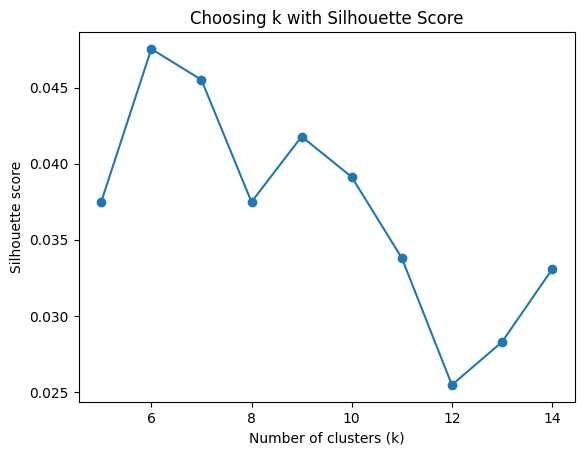

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(5, 15)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

[5 5 0 0 2 5 2 5 0 5 2 2 5 2 5 5 5 5 5 0 2 4 3 2 5 3 1 3 5 1 2 0 4 0 2 4 0
 1 5 0 3 0 1 2 3 2 0 3 3 0 4 1 3 3 3 3 3 0 3 0 0 1 3 3 1 2 3 3 3 2 2 4 2 3
 3 1 1 2 1 1 4 3 3 3 3 2 3 1 1 4 3 4 3 3 3 3 1 3 1 2 0 3 3 3 3 3 2 1 4 4 0
 3 4 1 0 1 4 4 1 1 1 4 1 3 5 1 3 1 3 3 4 3 3 1 1 1 3 0 1 3 3 2 4 4 4 4 1 1
 2 4 3 4 2 0 3 4 3 1 1 1]


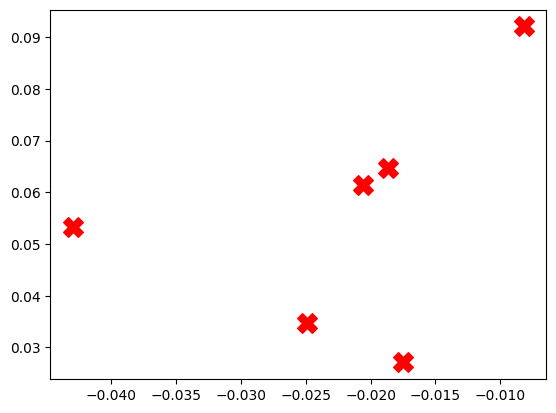

In [13]:
from sklearn.preprocessing import normalize

X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=6,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['description_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


### clustering title

In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['content'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Best k: 6
Best silhouette score: 0.28888208


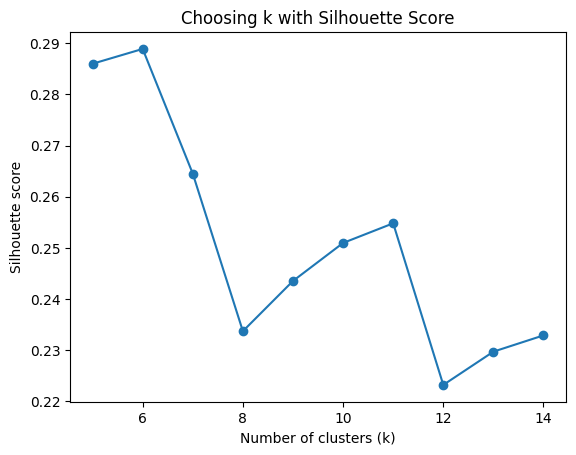

In [15]:

k_range = range(5, 15)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

[0 0 0 0 0 0 0 0 0 0 0 0 4 4 4 0 0 5 0 2 2 5 5 1 1 2 2 1 5 5 0 1 5 1 5 1 5
 5 5 5 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 3 0 0
 0 0 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 1 2 0 0 1
 0 0 0 2 2 2 2 2 0 0 1 1 1 2 2 0 2 2 0 3 3 0 2 5 0 0 1 2 1 5 0 3 0 2 0 2 2
 0 1 0 5 0 0 0 3 4 0 1 2]


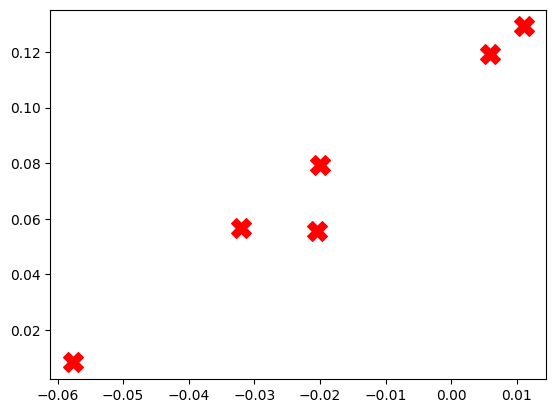

In [16]:
X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=6,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['title_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


# Vectorize video

In [21]:
# import torch
# import av
# import numpy as np

# from transformers import AutoProcessor, AutoModel


# MODEL_NAME = "microsoft/xclip-base-patch32"

# device = "cuda" if torch.cuda.is_available() else "cpu"

# processor = AutoProcessor.from_pretrained(MODEL_NAME)
# model = AutoModel.from_pretrained(MODEL_NAME).to(device)
# model.eval()


# def read_video(path, num_frames=8):
#     container = av.open(path)

#     stream = container.streams.video[0]
#     total_frames = stream.frames

#     indices = np.linspace(
#         0,
#         total_frames - 1,
#         num_frames,
#     ).astype(int)

#     frames = []

#     for i, frame in enumerate(container.decode(video=0)):
#         if i in indices:
#             frames.append(frame.to_ndarray(format="rgb24"))

#         if i > indices[-1]:
#             break

#     container.close()

#     return frames

# # num_frames uniformly sampled across video (supposedly model is optimized for 8)
# def video_embedding(path, num_frames=8):
#     video = read_video(path, num_frames)

#     inputs = processor(
#         videos=video,
#         return_tensors="pt",
#     )

#     inputs = {k: v.to(device) for k, v in inputs.items()}

#     with torch.no_grad():
#         embedding = model.get_video_features(**inputs).pooler_output

#     embedding = torch.nn.functional.normalize(embedding, dim=-1)

#     return embedding.cpu().numpy()[0]

Loading weights:   0%|          | 0/591 [00:00<?, ?it/s]

In [22]:
# from concurrent.futures import ThreadPoolExecutor, as_completed

# MAX_WORKERS = 4

# embeddings = {}
# with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
#     futures = {
#         ex.submit(video_embedding, str(vid)): vid
#         for vid in VIDEO_DIR.glob("*.mp4")
#     }
#     for future in as_completed(futures):
#         vid = futures[future]
#         embeddings[vid.stem] = future.result()

Best k: 10
Best silhouette score: 0.07887484


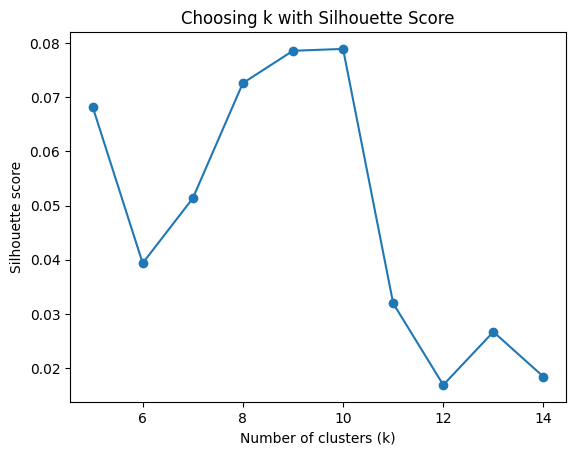

In [23]:
# X = np.array(list(embeddings.values()))

# k_range = range(5, 15)

# silhouette_scores = []

# for k in k_range:
#     clusterer = KMeans(
#         n_clusters=k,
#         random_state=42,
#         n_init="auto"
#     )
    
#     clusters = clusterer.fit_predict(X)
    
#     score = silhouette_score(X, clusters)
#     silhouette_scores.append(score)

# # Find best k
# best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

# print("Best k:", best_k)
# print("Best silhouette score:", max(silhouette_scores))

# # Plot
# plt.plot(k_range, silhouette_scores, marker="o")
# plt.xlabel("Number of clusters (k)")
# plt.ylabel("Silhouette score")
# plt.title("Choosing k with Silhouette Score")
# plt.show()

[3 2 4 0 3 3 3 3 1 0 3 1 0 0 0 2 3 3 0 4 2 3 2 3 2 0 3 3 2 0 4 0 4 4 1 3 3
 3 0 3 0 4 3 4 0 2 0 0 3 3 2 2 2 1 1 0 0 2 0 3 2 0 4 0 4 3 0 3 4 3 2 4 4 3
 3 0 3 3 3 2 3 3 3 3 0 3 0 0 2 1 3 4 0 3 3 3 2 3 2 0 0 1 0 0 4 4 3 0 3 2 0
 3 1 0 0 4 3 3 2 3 0 0 2 3 0 4 3 2 3 4 1 0 4 3 3 0 2 3 0 0 3 3 0 2 3 3 3 3
 3 3]


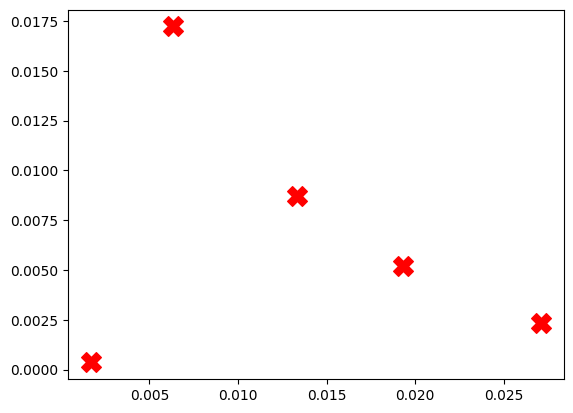

In [24]:
# X_normalized = normalize(X)

# clusterer = KMeans(
#     # n_clusters=best_k,
#     n_clusters=5,
#     random_state=42,
#     n_init="auto"
# )

# clusters = clusterer.fit_predict(X_normalized)
# print(clusters)
# described_posts['video_cluster'] = clusters

# centroids = clusterer.cluster_centers_
# plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


# feature engineering

In [17]:
from collections import Counter

import regex

POST_TITLE_COLUMN = "content"
HASHTAG_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_])#([\p{L}\p{N}_]+)")
MENTION_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_@])@([\p{L}\p{N}_][\p{L}\p{N}_.]*)")
EMOJI_PATTERN = regex.compile(
    r"(?:\p{Regional_Indicator}{2}|[#*0-9]\uFE0F?\u20E3|"
    r"\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?"
    r"(?:\u200D\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?)*)"
)


def _multi_hot_encode(frame, token_lists, prefix, column_name, min_frequency):
    if min_frequency < 1:
        raise ValueError("min_frequency must be at least 1")

    old_columns = [column for column in frame.columns if column.startswith(f"{prefix}_")]
    if old_columns:
        frame.drop(columns=old_columns, inplace=True)

    unique_tokens = token_lists.map(lambda tokens: list(dict.fromkeys(tokens)))
    frequencies = Counter(token for tokens in unique_tokens for token in tokens)
    vocabulary = sorted(token for token, count in frequencies.items() if count >= min_frequency)

    new_columns = {
        f"{prefix}_count": token_lists.map(len).astype("int16"),
        **{
            column_name(token): unique_tokens.map(
                lambda tokens, value=token: int(value in tokens)
            ).astype("int8")
            for token in vocabulary
        },
    }
    frame = pd.concat([frame, pd.DataFrame(new_columns, index=frame.index)], axis=1)
    return frame


def hashtag_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [tag.casefold() for tag in HASHTAG_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "hashtag", lambda tag: f"hashtag_{tag}", min_frequency
    )


def mention_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [mention.rstrip(".").casefold() for mention in MENTION_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "mention", lambda mention: f"mention_{mention}", min_frequency
    )


def emoji_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(EMOJI_PATTERN.findall)

    def emoji_column(value):
        codepoints = "_".join(f"{ord(char):x}" for char in value)
        return f"emoji_u{codepoints}"

    return _multi_hot_encode(frame, tokens, "emoji", emoji_column, min_frequency)


df = hashtag_encode(df)
df = mention_encode(df)
df = emoji_encode(df)
df.head()

,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,...,emoji_count,emoji_u270a,emoji_u27a1_fe0f,emoji_u1f3a8,emoji_u1f4fa,emoji_u1f64c,emoji_u1f680,emoji_u1f914,emoji_u1f929,emoji_u1faa7
11266,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=2eU9nF85n8o,#blackferns #blackfernssevens #rugbyunion #rug...,...,0,0,0,0,0,0,0,0,0,0
11273,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=0ezKVEUPjD8,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,0,0,0,0,0
11276,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=4u4reFc36Vg,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,0,0,0,0,0
11281,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=5SYrK9o7rEc,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,0,0,0,0,0
11293,Organic | Website,2025.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=45KEhHugLr8,#blackferns #rugbyunion #rugby #shorts #shorts,...,0,0,0,0,0,0,0,0,0,0


In [19]:
CATEGORICAL_COLUMNS = [
    "category_l0",
    "category_l1",
    "category_l2",
    "page",
    "platform",
]
CATEGORY_FIXED = "Missing Category"

for column in CATEGORICAL_COLUMNS:
    cleaned = df[column].fillna(CATEGORY_FIXED).astype(str).str.strip()
    cleaned = cleaned.replace({"": CATEGORY_FIXED})
    frame = pd.get_dummies(cleaned, prefix=f"cat_{column}")
    df = pd.concat([df, frame.astype("int8")], axis=1)
df.head()

,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,...,cat_category_l2_Sarah Hirini: Relentless,cat_category_l2_Sky,cat_category_l2_The Fischers,cat_category_l2_The Steam Team: One More,cat_category_l2_Together We Walk,cat_category_l2_WIP,cat_category_l2_WRWC 2025,cat_page_All Blacks,cat_page_Black Ferns,cat_platform_YT
11266,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=2eU9nF85n8o,#blackferns #blackfernssevens #rugbyunion #rug...,...,0,0,0,0,0,0,0,0,1,1
11273,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=0ezKVEUPjD8,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,0,0,0,1,1
11276,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=4u4reFc36Vg,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,0,0,0,1,1
11281,Organic | Website,2026.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=5SYrK9o7rEc,#blackferns #rugbyunion #rugby #shorts,...,0,0,0,0,0,0,0,0,1,1
11293,Organic | Website,2025.0,Black Ferns,YT,Short Video,Social,Teams Promo,Black Ferns,https://www.youtube.com/watch?v=45KEhHugLr8,#blackferns #rugbyunion #rugby #shorts #shorts,...,0,0,0,0,0,0,0,0,1,1


<Axes: >

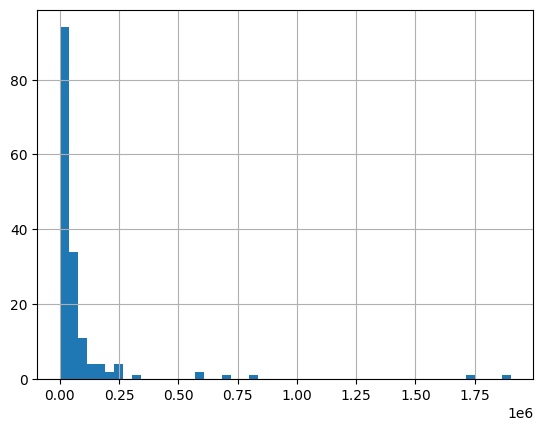

In [22]:
df['views'].hist(bins=50)

<Axes: >

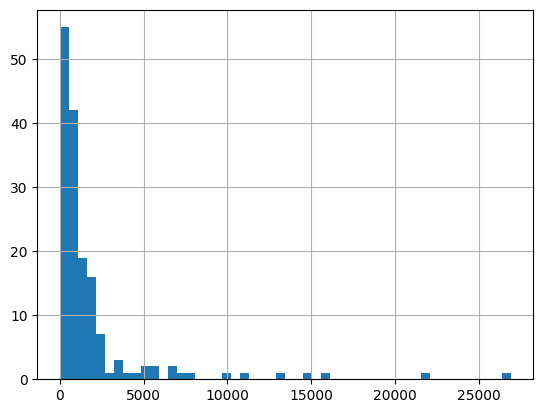

In [23]:
df['engagement'].hist(bins=50)

In [27]:
# pd.set_option('display.max_columns', None)
print(df.columns.tolist()) 

['campaign', 'year', 'page', 'platform', 'media_type', 'category_l0', 'category_l1', 'category_l2', 'url', 'content', 'cost_nzd', 'views', 'hours', 'engagement', 'description', 'json_content_theme_celebration', 'json_content_theme_challenges', 'json_content_theme_conversion', 'json_content_theme_haka', 'json_content_theme_kick', 'json_content_theme_non rugby related', 'json_content_theme_player story', 'json_content_theme_rivalry', 'json_content_theme_rugby_skills', 'json_content_theme_run', 'json_content_theme_tackle', 'json_content_theme_training', 'json_content_theme_try', 'json_format_access_announcement', 'json_format_access_archive', 'json_format_access_behind-the-scenes', 'json_format_access_candid clip', 'json_format_access_highlight', 'json_format_access_interview', 'json_format_access_montage', 'json_format_access_promotion', 'json_format_access_reaction', 'json_people_aaron cruden', 'json_people_aaron smith', 'json_people_agustin creevy', 'json_people_alama ieremia', 'json_p

## linreg views

In [29]:
DROP_COLS = ['campaign', 'year', 'page', 'platform', \
             'media_type', 'category_l0', 'category_l1', 'category_l2', \
             'url', 'content', 'cost_nzd', 'views', \
             'hours', 'engagement', 'description']

X = df.drop(columns=DROP_COLS)

y = np.log1p(df['views'])


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

128 32
128 32


Mean Squared Error (MSE): 3.2501
R-squared (R2) Score: -0.5169


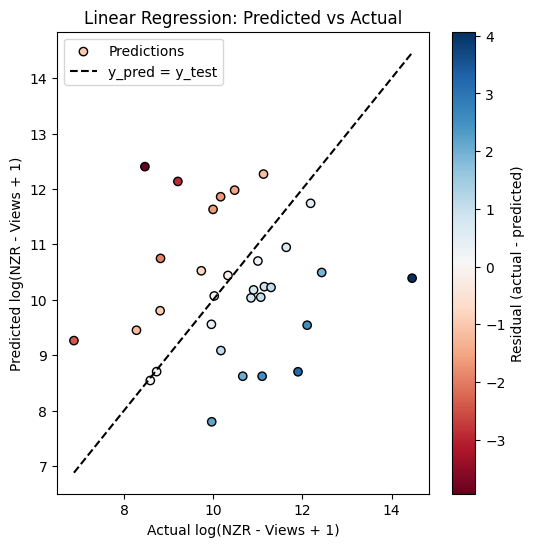

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# 7. Plot predicted vs actual with a y=x reference line.
y_test_array = np.asarray(y_test).ravel()
y_pred_array = np.asarray(y_pred).ravel()
residuals = y_test_array - y_pred_array
ref_min = float(min(y_test_array.min(), y_pred_array.min()))
ref_max = float(max(y_test_array.max(), y_pred_array.max()))

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    y_test_array, y_pred_array, c=residuals, cmap='RdBu',
    edgecolor='k', label='Predictions',
)
plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
plt.xlabel('Actual log(NZR - Views + 1)')
plt.ylabel('Predicted log(NZR - Views + 1)')
plt.title('Linear Regression: Predicted vs Actual')
plt.colorbar(scatter, label='Residual (actual - predicted)')
plt.legend()
plt.show()

In [32]:
# predicted views diff vs actual
diff = abs(round(np.expm1(y_pred) -  np.expm1(y_test)))
sorted(diff)

[176.0,
 246.0,
 1054.0,
 3494.0,
 7010.0,
 8764.0,
 9569.0,
 11369.0,
 15669.0,
 17373.0,
 18868.0,
 20289.0,
 28140.0,
 28630.0,
 37185.0,
 39705.0,
 40949.0,
 41454.0,
 53008.0,
 56490.0,
 60438.0,
 70021.0,
 90599.0,
 115426.0,
 123635.0,
 141444.0,
 144811.0,
 167061.0,
 176399.0,
 214624.0,
 238701.0,
 1870105.0]

In [33]:
important_features = sorted(zip(model.coef_, X_train.columns))

print('top 5 negative:')
for t in important_features[:5]:
    print(t[0], t[1])

print('top 5 positive:')
for t in reversed(important_features[-5:]):
    print(t[0], t[1])


top 5 negative:
-4.5260055887061 json_brands_shotover jet
-1.7567799604435907 json_format_access_interview
-1.7273387972903618 json_tone_wholesome
-1.34104458530602 json_brands_dude perfect
-1.341044585306012 json_people_dude perfect
top 5 positive:
2.655135950487728 json_brands_all blacks
1.9577593548548453 json_overall_team_women
1.2899809111005918 json_context_tour
1.262728467031777 json_tone_solemn
1.1577124743443572 json_context_pre-match


## linreg engagement

In [35]:
X = df.drop(columns=DROP_COLS)

y = np.log1p(df['engagement'])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

128 32
128 32


Mean Squared Error (MSE): 3.5902
R-squared (R2) Score: -0.5700


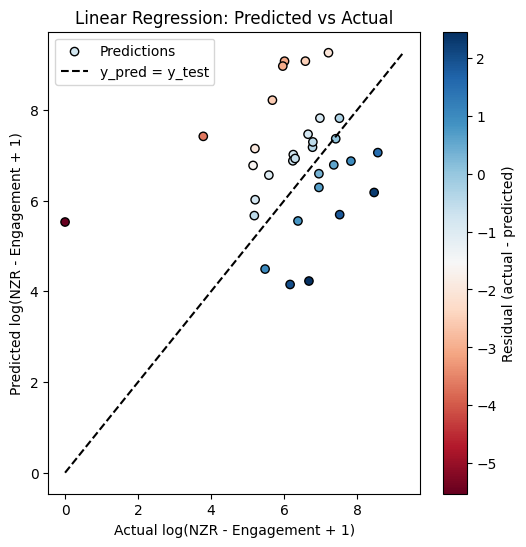

In [38]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

y_test_array = np.asarray(y_test).ravel()
y_pred_array = np.asarray(y_pred).ravel()
residuals = y_test_array - y_pred_array
ref_min = float(min(y_test_array.min(), y_pred_array.min()))
ref_max = float(max(y_test_array.max(), y_pred_array.max()))

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    y_test_array, y_pred_array, c=residuals, cmap='RdBu',
    edgecolor='k', label='Predictions',
)
plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
plt.xlabel('Actual log(NZR - Engagement + 1)')
plt.ylabel('Predicted log(NZR - Engagement + 1)')
plt.title('Linear Regression: Predicted vs Actual')
plt.colorbar(scatter, label='Residual (actual - predicted)')
plt.legend()
plt.show()

In [39]:
diff = abs(round(np.expm1(y_pred) - np.expm1(y_test)))
sorted(diff)

[78.0,
 112.0,
 150.0,
 229.0,
 250.0,
 314.0,
 331.0,
 411.0,
 431.0,
 442.0,
 458.0,
 476.0,
 504.0,
 585.0,
 594.0,
 648.0,
 682.0,
 703.0,
 726.0,
 966.0,
 1088.0,
 1410.0,
 1545.0,
 1546.0,
 1617.0,
 3396.0,
 4072.0,
 4250.0,
 7429.0,
 7997.0,
 8304.0,
 9141.0]

In [40]:
important_features = sorted(zip(model.coef_, X_train.columns))

print('top 5 negative:')
for t in important_features[:5]:
    print(t[0], t[1])

print('top 5 positive:')
for t in reversed(important_features[-5:]):
    print(t[0], t[1])

top 5 negative:
-2.068315890687803 json_brands_shotover jet
-1.5980144260113893 json_brands_dude perfect
-1.5980144260113864 json_people_dude perfect
-1.0312721666313869 json_event_sevens
-0.8054106383625665 json_content_theme_non rugby related
top 5 positive:
0.8172350533693838 json_tone_solemn
0.7552496857965894 json_brands_all blacks
0.6974195480668339 json_people_canada rugby team
0.6705582069286574 json_tone_humour
0.6433464147674804 json_people_sylvia brunt


## linreg views + engagement (multivariate)

In [39]:
X = described_posts.drop(columns=DROP_COLS)

y = np.log1p(described_posts[['NZR - Views', 'NZR - Engagement']])

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

120 30
120 30


NZR - Views - Mean Squared Error (MSE): 10.5633
NZR - Views - R-squared (R2) Score: -1.2029
NZR - Engagement - Mean Squared Error (MSE): 8.8321
NZR - Engagement - R-squared (R2) Score: -0.8871


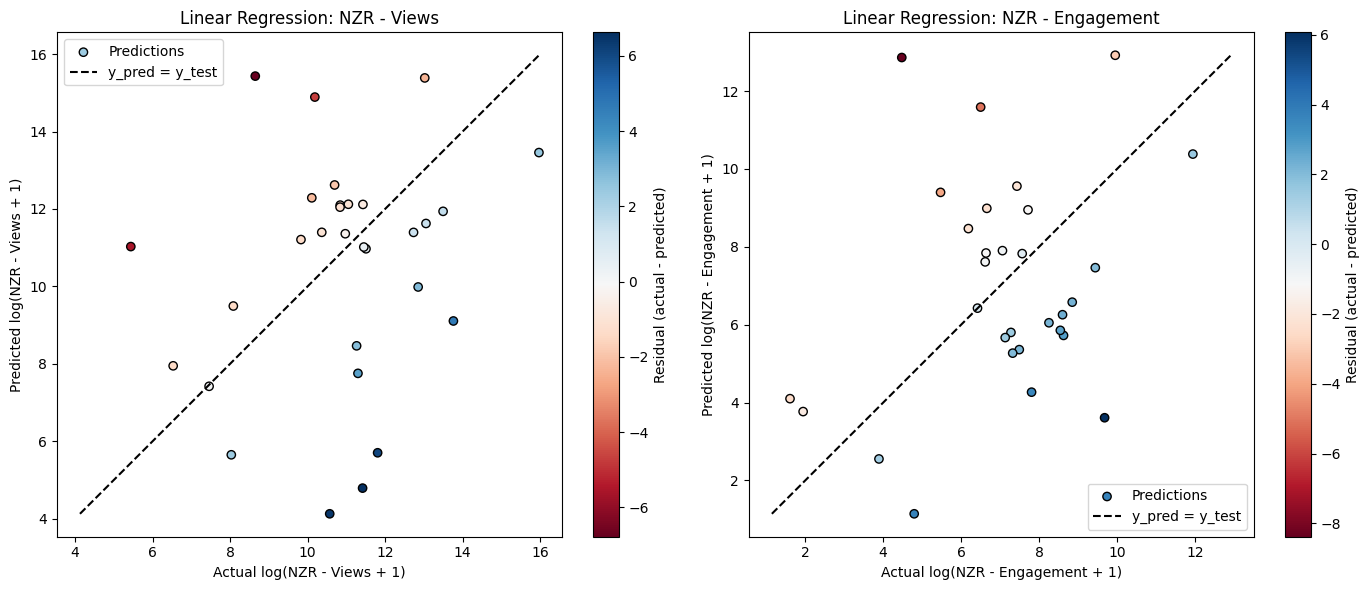

In [41]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

targets = ['NZR - Views', 'NZR - Engagement']
for i, name in enumerate(targets):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"{name} - Mean Squared Error (MSE): {mse:.4f}")
    print(f"{name} - R-squared (R2) Score: {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (ax, name) in enumerate(zip(axes, targets)):
    y_test_array = np.asarray(y_test.iloc[:, i]).ravel()
    y_pred_array = np.asarray(y_pred[:, i]).ravel()
    residuals = y_test_array - y_pred_array
    ref_min = float(min(y_test_array.min(), y_pred_array.min()))
    ref_max = float(max(y_test_array.max(), y_pred_array.max()))
    scatter = ax.scatter(
        y_test_array, y_pred_array, c=residuals, cmap='RdBu',
        edgecolor='k', label='Predictions',
    )
    ax.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
    ax.set_xlabel(f'Actual log({name} + 1)')
    ax.set_ylabel(f'Predicted log({name} + 1)')
    ax.set_title(f'Linear Regression: {name}')
    fig.colorbar(scatter, ax=ax, label='Residual (actual - predicted)')
    ax.legend()
plt.tight_layout()
plt.show()

In [42]:
for i, name in enumerate(targets):
    diff = abs(round(np.expm1(y_pred[:, i]) - np.expm1(y_test.iloc[:, i])))
    print(name)
    print(sorted(diff))

NZR - Views
[66.0, 2144.0, 2791.0, 10023.0, 27555.0, 33070.0, 38902.0, 41160.0, 55226.0, 57251.0, 61328.0, 73248.0, 78427.0, 90870.0, 91065.0, 119543.0, 120666.0, 128581.0, 133857.0, 192303.0, 250022.0, 257931.0, 355317.0, 360000.0, 573152.0, 938685.0, 2899654.0, 4344930.0, 5023060.0, 7917493.0]
NZR - Engagement
[3.0, 36.0, 36.0, 55.0, 118.0, 572.0, 960.0, 1118.0, 1278.0, 1321.0, 1539.0, 1581.0, 1780.0, 2388.0, 3418.0, 4276.0, 4794.0, 4920.0, 5279.0, 5460.0, 6259.0, 7231.0, 10866.0, 11838.0, 12483.0, 15981.0, 107250.0, 121983.0, 385417.0, 387498.0]


In [43]:
for i, name in enumerate(targets):
    important_features = sorted(zip(model.coef_[i], X_train.columns))

    print(f'top 5 negative ({name}):')
    for t in important_features[:5]:
        print(t[0], t[1])

    print(f'top 5 positive ({name}):')
    for t in reversed(important_features[-5:]):
        print(t[0], t[1])

top 5 negative (NZR - Views):
-3.3859118672052038 emoji_u1f62e_200d_1f4a8
-2.81383653683669 hashtag_chicago
-2.5728379888882476 hashtag_wellington
-2.5274574877203477 emoji_u1f381
-2.217787531783899 emoji_u1f512
top 5 positive (NZR - Views):
6.379990038746026 hashtag_rugby
3.512049604356811 hashtag_blackfernssevens
3.0420810467205364 hashtag_nz
2.995990742752318 hashtag_hk7s
2.802169780685565 hashtag_football
top 5 negative (NZR - Engagement):
-4.261081167441169 hashtag_chicago
-4.005554550864094 emoji_u1f62e_200d_1f4a8
-3.9875802237539295 hashtag_wellington
-3.529972972384898 hashtag_haka
-3.445594249988581 hashtag_sports
top 5 positive (NZR - Engagement):
4.9403225003654585 emoji_u27a1_fe0f
4.704841098466701 hashtag_rugby
3.883097834834119 emoji_u1f4f2
3.1875334006684 hashtag_hk7s
3.0794261538896364 cat_NZR - Platform Code_IG
